In [1]:
import numpy as np
import rldurham as rld

In [2]:
env = rld.make(
  #  'FrozenLake-v1',         # small version
     'FrozenLake8x8-v1',    # larger version
    # desc=["GFFS", "FHFH", "FFFH", "HFFG"],  # custom map
    render_mode="rgb_array", # for rendering as image/video
    is_slippery=False,       # warning: slippery=True results in complex dynamics
)
rld.env_info(env, print_out=True)
rld.seed_everything(42, env)
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3

Seed set to 42


actions are discrete with 4 dimensions/#actions
observations are discrete with 64 dimensions/#observations
maximum timesteps is: 200


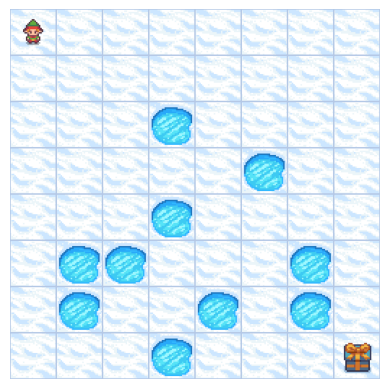

In [3]:
rld.render(env)

64 4
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25

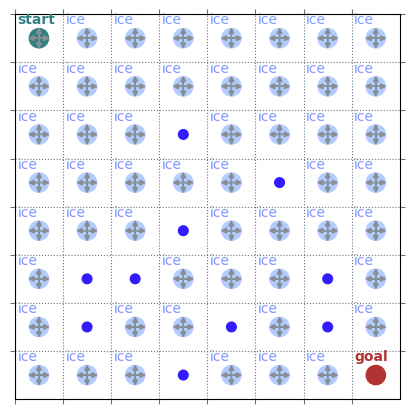

In [9]:
print(env.observation_space.n, env.action_space.n)
def uniform_policy(env):
    # [:64][:4] = 1     /4 每个动作概率相同
    return np.ones((env.observation_space.n, env.action_space.n)) / env.action_space.n
rld.plot_frozenlake(env=env, policy=uniform_policy(env))

In [10]:
def policy_eval_step(env, policy, gamma, v_init=None):
    """
    
    :param env: 
    :param policy: 
    :param gamma: discount factor
    :param v_init: 旧的状态价值向量
    :return: 
    """
    if v_init is None:
        v_init = np.zeros(env.observation_space.n)
    v = np.zeros(env.observation_space.n)
    for s_from in range(env.observation_space.n):
        for a in range(env.action_space.n):
            pi = policy[s_from, a]
            for p, s_to, r, done in env.P[s_from][a]:
                # 累加：p发送概率*环境让我转到p的概率 * (即时奖励 + 折扣后的未来价值)
                v[s_from] += pi * p * (r + gamma * v_init[s_to])
    return v

In [12]:
v = np.zeros(env.observation_space.n)
print(v)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


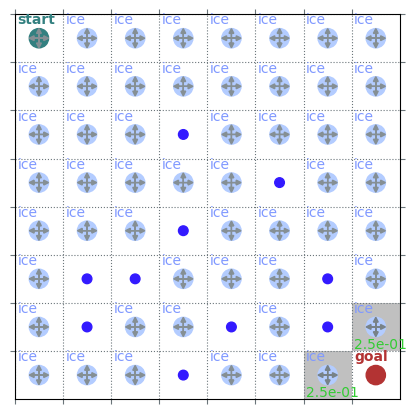

In [13]:
v = policy_eval_step(env, uniform_policy(env), 1, v)
rld.plot_frozenlake(env, v, uniform_policy(env), draw_vals=True)

In [14]:
def policy_eval_step_inplace(env, policy, gamma, v_init=None):
    if v_init is None:
        v_init = np.zeros(env.observation_space.n)
    v = v_init.copy() # opearate on copy in-place
    # 反向是因为goal才有value， value通过goal向start传播，越靠近goal价值越高
    for s_from in reversed(range(env.observation_space.n)):  # reverse order of states
        v_s_from = 0  # compute value for this state
        for a in range(env.action_space.n):
            pi = policy[s_from, a]
            for p, s_to, r, done in env.P[s_from][a]:
                v_s_from += pi * p * (r + gamma * v[s_to])  # use the values we also update
        v[s_from] = v_s_from  # update
    return v

In [15]:
v = np.zeros(env.observation_space.n)

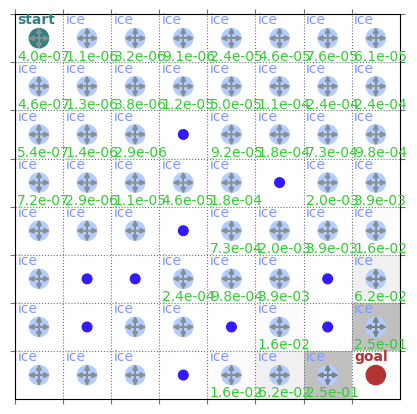

In [16]:
v = policy_eval_step_inplace(env, uniform_policy(env), 1, v)
rld.plot_frozenlake(env, v, uniform_policy(env), draw_vals=True)

In [17]:
def policy_evaluation(env, policy, gamma, v_init=None, print_iter=False, atol=1e-8, max_iter=10**10):
    if v_init is None:
        v_init = np.zeros(env.observation_space.n)
    v = v_init
    for i in range(1, max_iter + 1):
        new_v = policy_eval_step(env, policy, gamma, v)
        # new_v = policy_eval_step_inplace(env, policy, gamma, v)
        if np.allclose(v, new_v, atol=atol):
            break
        v = new_v
    if print_iter:
        print(f"{i} iterations")
    return v

230 iterations


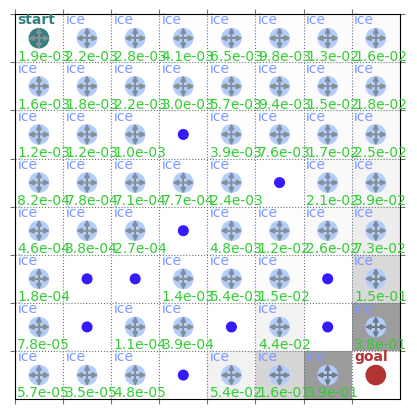

In [18]:
v = policy_evaluation(env, uniform_policy(env), 1, print_iter=True)
rld.plot_frozenlake(env, v, uniform_policy(env), draw_vals=True)